# Moments: was the space used? (Phase 3)

Sanity checks and showcase for the action metrics from `scripts/build_actions.py` (one row per
open-play pass, cross or carry; see `docs/methodology.md` section 9):

1. Coverage: which actions are computed, and where the chosen point comes from.
2. Does the model make sense? The attacker who *owns* the chosen space should usually be the
   receiver, and choosing higher-xSpace targets should gain more xT.
3. Zones targeted and completion.
4. Thresholds, teams and players (aggregates, both sources).
5. **Moments**: the top 20 exploited and top 20 missed opportunities, drawn on the pitch.

Frame-level figures use IDSSE only (CC BY 4.0); PFF appears in aggregates and tables only.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from xspace.config import ACTIONS_DIR
from xspace.metrics.space import ZONES
from xspace.metrics.timeline import read_timeline

parts, meta = [], {}
for path in sorted(ACTIONS_DIR.glob("*.parquet")):
    df, m = read_timeline(path)
    df.insert(0, "source", m["source"])
    df.insert(1, "match_id", m["match_id"])
    df["team"] = np.where(df["team_side"] == 0, m["home"], m["away"])
    parts.append(df)
    meta[(m["source"], m["match_id"])] = m
acts = pd.concat(parts, ignore_index=True)
acts["completed"] = acts["success"].fillna(False).astype(bool)
acts["zone"] = pd.Categorical.from_codes(acts["chosen_zone"].fillna(-1).astype(int), ZONES)
ok = acts[acts["status"] == "ok"].copy()
print(f"{len(meta)} matches, {len(acts):,} actions, {len(ok):,} computed; params hashes:",
      sorted({m['params_hash'] for m in meta.values()}),
      "; git:", sorted({m['git_sha'] for m in meta.values()}))

71 matches, 68,464 actions, 65,584 computed; params hashes: ['7faba5708c37'] ; git: ['4bcd2fbece4a-dirty']


## 1. Coverage

In [2]:
display(acts.groupby("source")["status"].value_counts(normalize=True).unstack().mul(100).round(1))
display(acts.groupby("source")["chosen_source"].value_counts(normalize=True).unstack().mul(100).round(1))
display(acts.groupby(["source", "type"], observed=True).size().unstack(fill_value=0))

status,ok,quality,no_frame,no_target
source,,,,
idsse,98.5,0.0,1.3,0.1
pff,95.6,0.3,4.0,0.1


chosen_source,end,target,next_event,none
source,,,,
idsse,75.8,0.0,23.5,0.7
pff,81.4,16.8,0.9,0.9


type,pass,cross,carry
source,,,
idsse,5381,0,0
pff,60520,1713,850


## 2. Does it make sense?

**Space owner = receiver.** For completed passes, the attacker with the largest pitch-control
share at the chosen cell should be the player who actually received the ball.

In [3]:
c = ok[ok["completed"] & ok["receiver_player_id"].notna() & (ok["type"] != "carry")]
print((c["owner_id"] == c["receiver_player_id"]).groupby(c["source"]).mean().round(3))

source
idsse     0.76
pff      0.847
dtype: double[pyarrow]


**Choosing more xSpace gains more xT.** Actions binned by the chosen point's rank within its
frame. For completed actions, mean xT gained should rise with the rank; completion should
fall, because the most valuable space is the hardest to reach.

,actions,completion,xt_gained_if_completed,xt_gained_all
rank_bin,,,,
0 (no value),25778,0.9174,-0.0026,-0.0046
≤25%,2080,0.8394,0.0112,0.0044
25–50%,7644,0.9100,0.0034,0.0011
50–75%,14460,0.8578,0.0041,0.0010
75–90%,9375,0.6631,0.0075,-0.0006
top 10%,6247,0.4537,0.0168,-0.0039


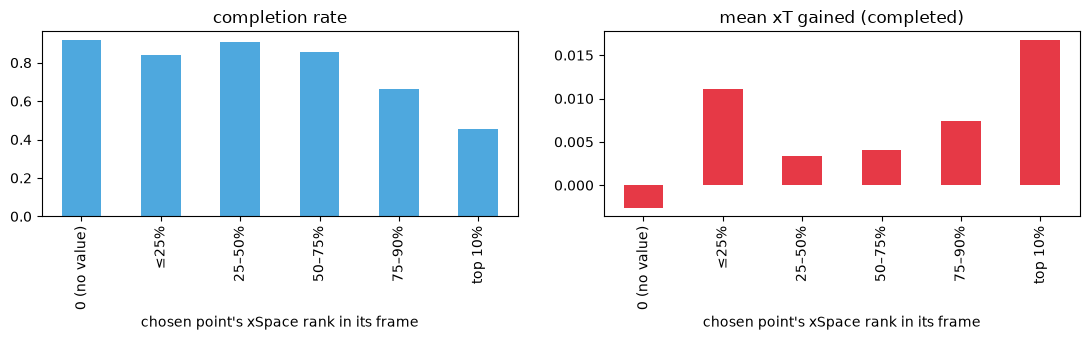

In [4]:
ok["rank_bin"] = pd.cut(ok["chosen_rank"], [-0.01, 0, 0.25, 0.5, 0.75, 0.9, 1.0],
                        labels=["0 (no value)", "≤25%", "25–50%", "50–75%", "75–90%", "top 10%"])
comp = ok[ok["completed"]]
tab = pd.DataFrame({
    "actions": ok.groupby("rank_bin", observed=True).size(),
    "completion": ok.groupby("rank_bin", observed=True)["completed"].mean(),
    "xt_gained_if_completed": comp.groupby("rank_bin", observed=True)["xt_gained"].mean(),
    "xt_gained_all": ok.groupby("rank_bin", observed=True)["xt_gained"].mean(),
})
display(tab.round(4))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
tab["completion"].plot.bar(ax=ax[0], color="#4ea8de", title="completion rate")
tab["xt_gained_if_completed"].plot.bar(ax=ax[1], color="#e63946",
                                       title="mean xT gained (completed)")
for a in ax:
    a.set_xlabel("chosen point's xSpace rank in its frame")
plt.tight_layout()

## 3. Zones targeted (actions into positive xSpace)

In [5]:
z = ok[ok["chosen"] > 0].groupby(["source", "zone"], observed=True).agg(
    share=("chosen", "size"), completion=("completed", "mean"),
    mean_xt_gained=("xt_gained", "mean"))
z["share"] = z["share"] / z.groupby("source")["share"].transform("sum")
display(z.round(3))

share  completion  mean_xt_gained
source zone                                       
idsse  behind    0.255       0.544           0.003
       between   0.203       0.625          -0.001
       wide      0.086       0.813           0.001
       in_front  0.456       0.860          -0.001
pff    behind    0.188       0.591           0.007
       between   0.199       0.547          -0.006
       wide      0.098       0.787          -0.001
       in_front  0.515       0.899          -0.000

## 4. Thresholds, teams and players

`exploited` and `missed` use starting thresholds (`ExploitationConfig`). Their rates by source:

In [6]:
display(ok.groupby("source")[["exploited", "missed"]].mean().mul(100).round(2))
print("frame best-cell percentiles:",
      ok["best"].quantile([.5, .75, .9, .95, .99]).round(4).to_dict())

,exploited,missed
source,,
idsse,1.23,3.36
pff,0.80,1.90


frame best-cell percentiles: {0.5: 0.0109, 0.75: 0.0163, 0.9: 0.0306, 0.95: 0.0428, 0.99: 0.0675}


In [7]:
team = ok.groupby(["source", "match_id", "team"]).agg(
    actions=("chosen", "size"), exploited=("exploited", "sum"), missed=("missed", "sum"),
    decision_gap=("decision_gap", "mean"), chosen_rank=("chosen_rank", "mean")).reset_index()
by_team = team.groupby("team").agg(matches=("match_id", "size"),
                                   exploited_per_match=("exploited", "mean"),
                                   missed_per_match=("missed", "mean"),
                                   mean_decision_gap=("decision_gap", "mean"),
                                   mean_chosen_rank=("chosen_rank", "mean"))
print("Most exploited space per match (≥ 3 matches):")
display(by_team[by_team.matches >= 3].sort_values("exploited_per_match", ascending=False)
        .head(10).round(3))

Most exploited space per match (≥ 3 matches):


,matches,exploited_per_match,missed_per_match,mean_decision_gap,mean_chosen_rank
team,,,,,
Germany,3,8.000,15.000,0.014,0.389
Denmark,3,6.333,9.667,0.012,0.406
Spain,4,6.000,13.000,0.013,0.355
France,7,5.429,9.286,0.013,0.398
Mexico,3,5.333,12.333,0.014,0.438
South Korea,4,5.250,12.500,0.014,0.391
Portugal,5,5.200,8.400,0.011,0.372
Fortuna Düsseldorf,5,5.200,14.800,0.013,0.383
Canada,3,5.000,10.667,0.013,0.397


In [8]:
players = ok[ok["type"] != "carry"].groupby(["source", "team", "player_id"]).agg(
    actions=("chosen", "size"), exploited=("exploited", "sum"), missed=("missed", "sum"),
    chosen_rank=("chosen_rank", "mean"), decision_gap=("decision_gap", "mean")).reset_index()
players = players[players["actions"] >= 150]
players["exploit_rate"] = players["exploited"] / players["actions"]
print(f"{len(players)} players with ≥ 150 passes; highest exploitation rate:")
display(players.sort_values("exploit_rate", ascending=False).head(10).round(3))

125 players with ≥ 150 passes; highest exploitation rate:


,source,team,player_id,actions,exploited,missed,chosen_rank,decision_gap,exploit_rate
399,pff,France,3870,207,8,16,0.360,0.021,0.039
393,pff,France,1532,184,6,9,0.387,0.019,0.033
113,idsse,Fortuna Düsseldorf,DFL-OBJ-00028V,165,5,3,0.346,0.012,0.030
167,pff,Argentina,1531,316,9,13,0.359,0.014,0.028
394,pff,France,1534,270,7,4,0.363,0.014,0.026
331,pff,Croatia,8136,239,6,9,0.465,0.014,0.025
653,pff,Senegal,13228,175,4,2,0.361,0.015,0.023
325,pff,Croatia,4883,157,3,9,0.210,0.017,0.019
737,pff,Switzerland,157,216,4,2,0.320,0.011,0.019
728,pff,Spain,4908,169,3,8,0.263,0.017,0.018


## 5. Moments (IDSSE)

Top 20 **exploited** (ranked by xSpace at the chosen point) and top 20 **missed** (ranked by
decision gap) across the 7 IDSSE matches. Each panel: xSpace at the release frame (attacking
→), attackers red (hollow = offside, left out of pitch control), defenders blue, ball white,
the action as an arrow to the chosen point, and the frame's best cell as a yellow star.

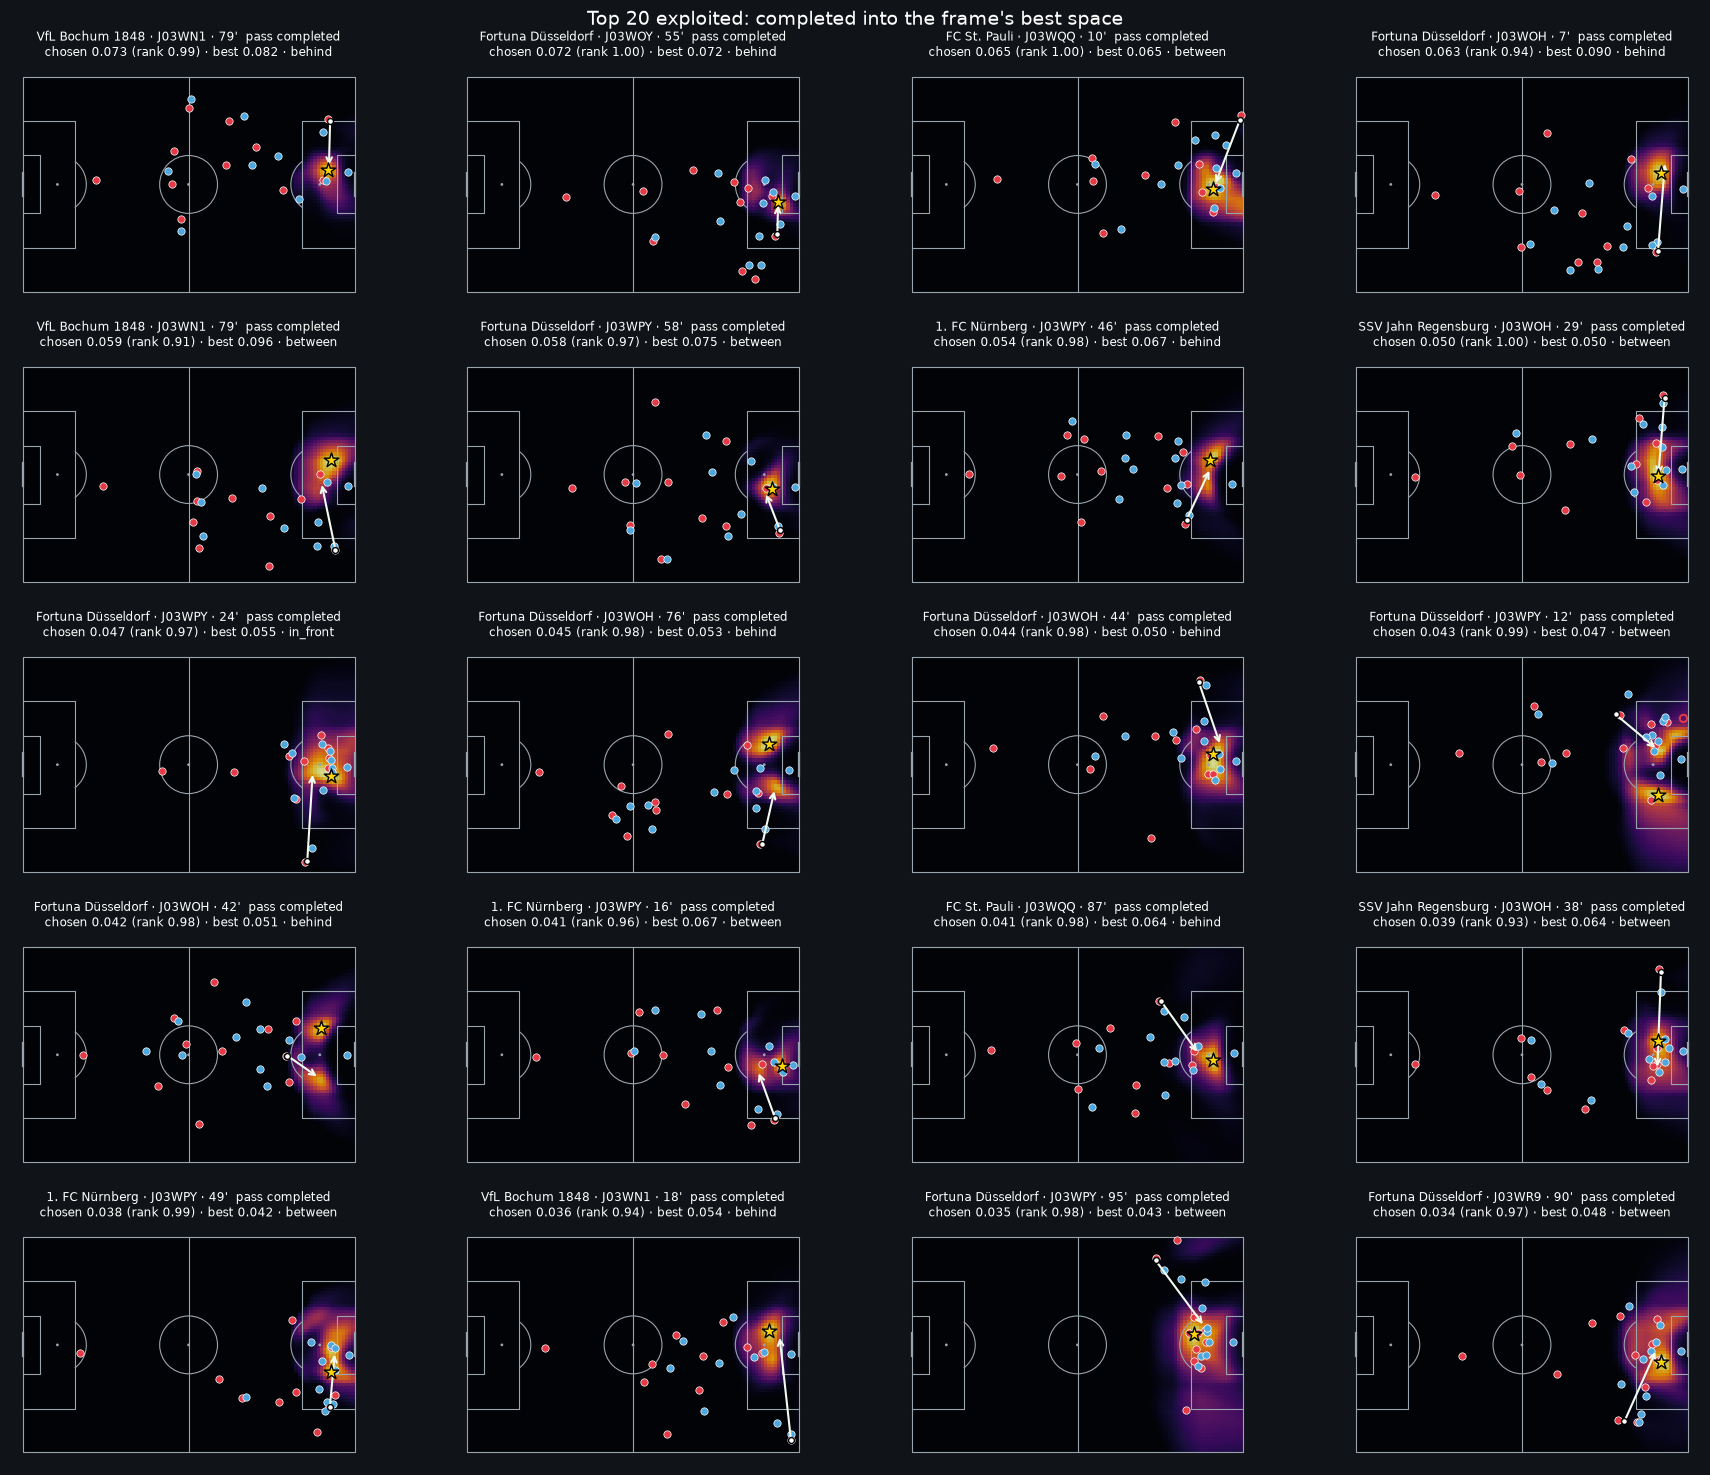

In [9]:
from mplsoccer import Pitch

from xspace.metrics.space import frame_space, orient
from xspace.physics.pitch_control import make_grid
from xspace.pipeline import prepare_match

xs, ys, grid = make_grid(1.0)
_cache = {}


def prepared(match_id):
    if match_id not in _cache:
        _cache[match_id] = prepare_match("idsse", match_id)
    return _cache[match_id]


def draw(rows, title):
    pitch = Pitch(pitch_type="custom", pitch_length=105, pitch_width=68, line_zorder=3,
                  pitch_color="#101418", line_color="#9aa4ad", linewidth=0.8)
    fig, axes = plt.subplots(5, 4, figsize=(18, 15))
    for ax, (_, r) in zip(axes.flat, rows.iterrows(), strict=False):
        m, f, side = prepared(r.match_id).match, int(r.frame), int(r.team_side)
        fs = frame_space(m, f, grid, side=side)
        pitch.draw(ax=ax)
        ax.imshow(fs.xspace.reshape(len(ys), len(xs)), extent=(0, 105, 0, 68), origin="lower",
                  cmap="inferno", vmin=0, vmax=max(fs.xspace.max(), 1e-6), alpha=0.85, zorder=1)
        for s, colour in ((side, "#e63946"), (1 - side, "#4ea8de")):
            p = orient(m.team_arrays(s)[0][f], side)
            if s == side and fs.offside.any():  # offside attackers: hollow, own no space
                ax.scatter(p[fs.offside, 0] + 52.5, p[fs.offside, 1] + 34, facecolors="none",
                           ec=colour, s=28, lw=1.4, zorder=4)
                p = p[~fs.offside]
            ax.scatter(p[:, 0] + 52.5, p[:, 1] + 34, c=colour, s=28, ec="white", lw=0.5,
                       zorder=4)
        b = orient(m.ball[f], side)
        ax.scatter(b[0] + 52.5, b[1] + 34, c="white", s=18, ec="black", zorder=6)
        ax.annotate("", xy=(r.chosen_x + 52.5, r.chosen_y + 34),
                    xytext=(b[0] + 52.5, b[1] + 34),
                    arrowprops=dict(arrowstyle="->", color="#f1faee", lw=1.5), zorder=5)
        ax.scatter(r.best_x + 52.5, r.best_y + 34, marker="*", c="#ffd60a", s=120,
                   ec="black", zorder=6)
        minute = int(r.time_s // 60) + (45 if r.period == 2 else 0)
        ax.set_title(f"{r.team} · {r.match_id} · {minute}'  {r.type} "
                     f"{'completed' if r.completed else 'lost'}\n"
                     f"chosen {r.chosen:.3f} (rank {r.chosen_rank:.2f}) · best {r.best:.3f} · "
                     f"{r.zone}", color="white", fontsize=8.5)
    for ax in axes.flat[len(rows):]:
        ax.axis("off")
    fig.patch.set_facecolor("#101418")
    fig.suptitle(title, color="white", fontsize=14)
    plt.tight_layout()


idsse = ok[ok["source"] == "idsse"]
top_exploited = idsse[idsse["exploited"]].sort_values("chosen", ascending=False).head(20)
draw(top_exploited, "Top 20 exploited: completed into the frame's best space")

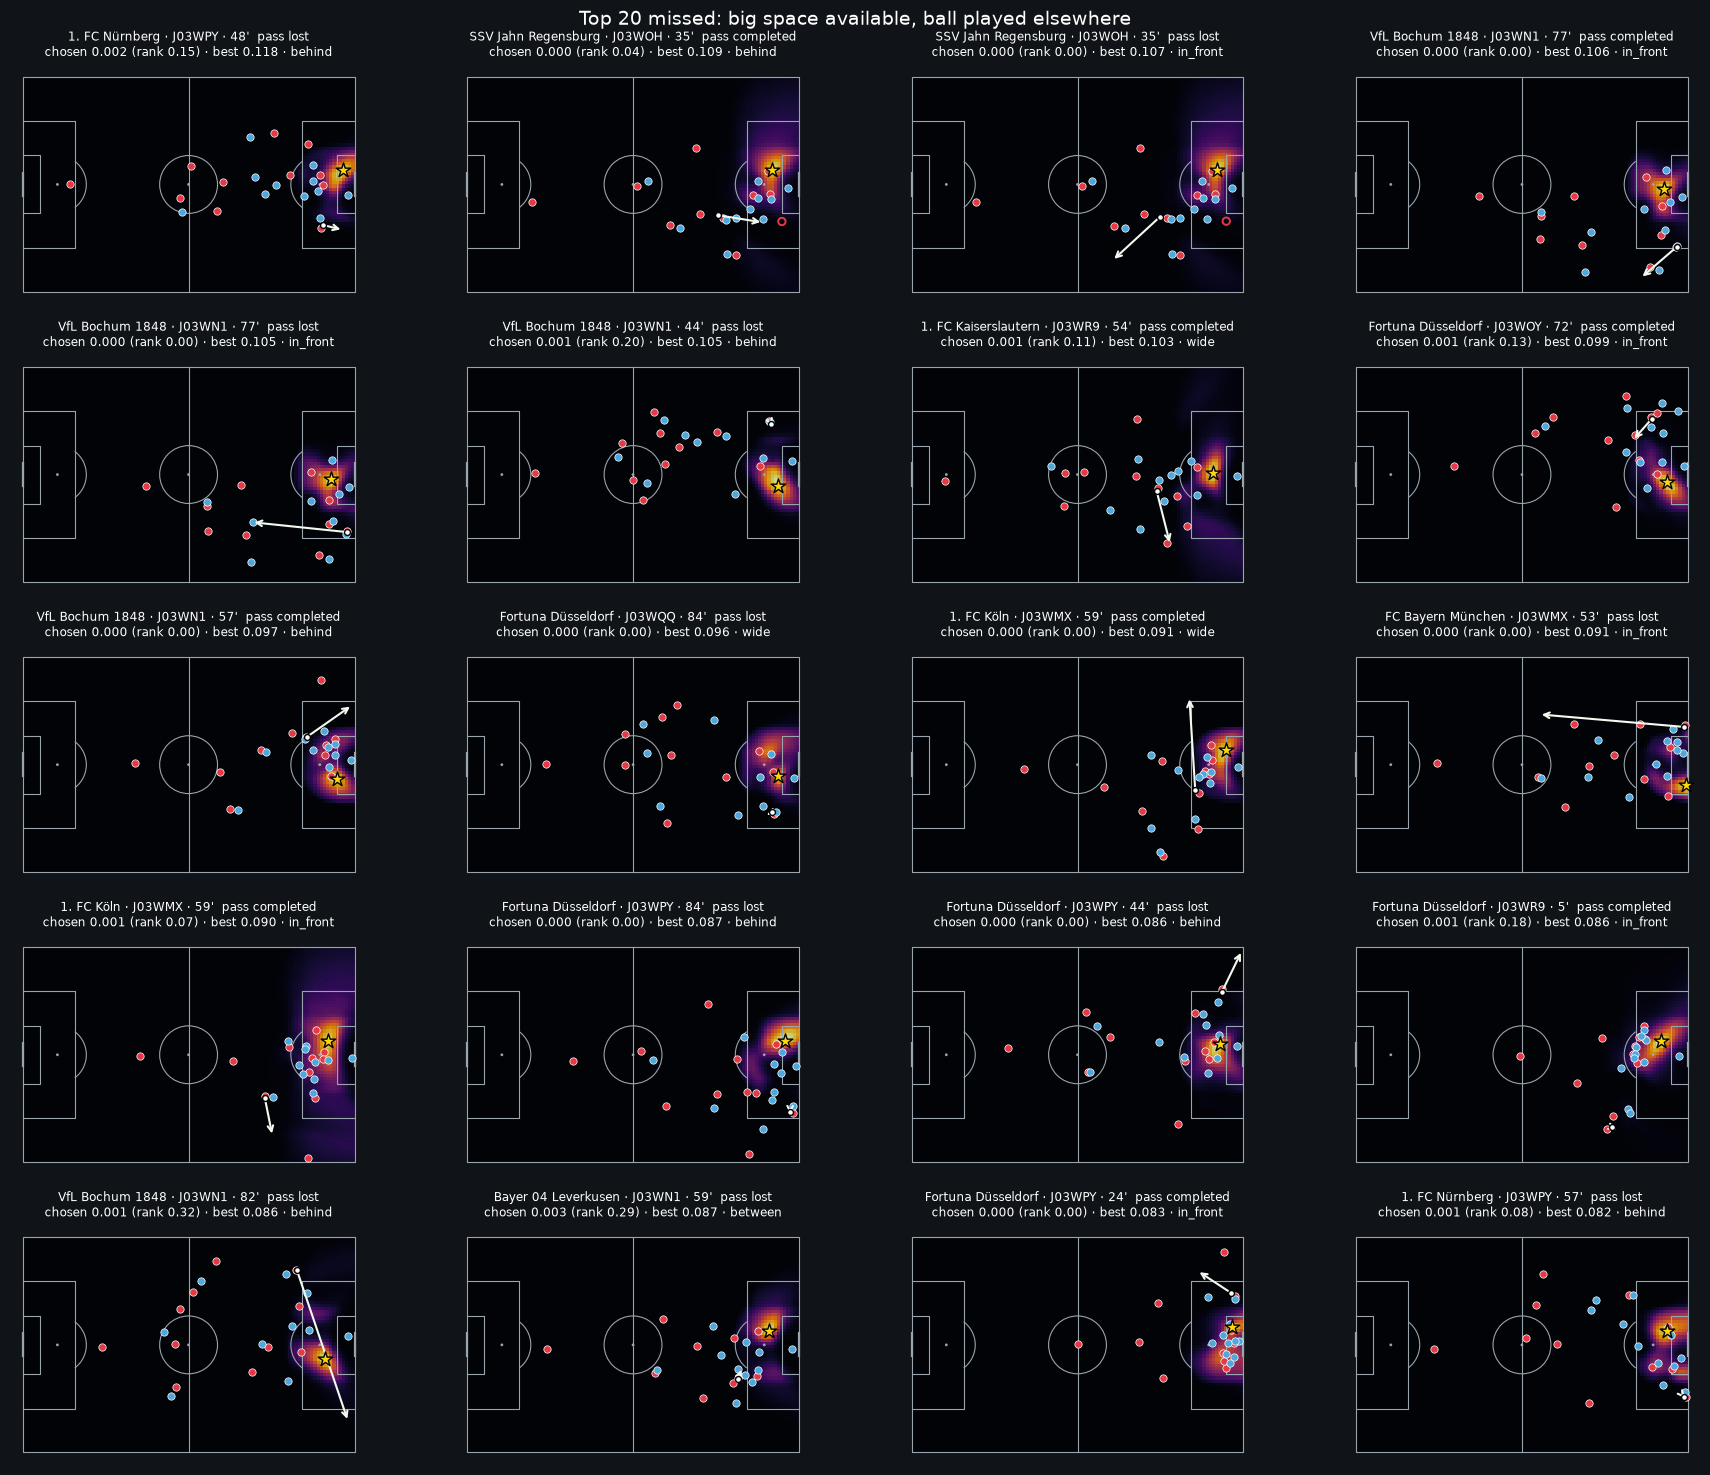

In [10]:
top_missed = idsse[idsse["missed"]].sort_values("decision_gap", ascending=False).head(20)
draw(top_missed, "Top 20 missed: big space available, ball played elsewhere")

### World Cup (PFF): tables only

PFF's top moments are listed without frame figures; check them against video via PFF's
`videoUrl`.

In [11]:
cols = ["match_id", "team", "period", "time_s", "player_id", "type", "completed", "zone",
        "chosen", "chosen_rank", "best", "decision_gap"]
pff = ok[ok["source"] == "pff"]
print("Top 10 exploited")
display(pff[pff["exploited"]].sort_values("chosen", ascending=False)[cols].head(10).round(3))
print("Top 10 missed")
display(pff[pff["missed"]].sort_values("decision_gap", ascending=False)[cols].head(10).round(3))

Top 10 exploited


,match_id,team,period,time_s,player_id,type,completed,zone,chosen,chosen_rank,best,decision_gap
61702,3852,Belgium,2,2679.446,4684,cross,True,behind,0.093,0.977,0.115,0.022
19798,10515,France,1,2113.180,3888,pass,True,between,0.083,0.968,0.108,0.024
65755,3856,Uruguay,2,2590.057,13929,cross,True,behind,0.076,0.957,0.102,0.026
32239,3822,Spain,1,1230.864,1513,pass,True,behind,0.067,0.997,0.071,0.004
61227,3852,Belgium,2,180.013,22,cross,True,behind,0.063,0.978,0.079,0.016
50961,3841,South Korea,2,3025.325,13911,cross,True,between,0.063,0.995,0.067,0.004
37076,3826,Ghana,2,2606.673,5085,cross,True,behind,0.063,0.974,0.090,0.028
58703,3850,Argentina,1,118.953,6895,cross,True,behind,0.062,0.998,0.062,0.000
28911,3819,Australia,1,503.036,13815,cross,True,behind,0.061,0.979,0.073,0.012
67286,3858,Serbia,2,902.165,1702,cross,True,between,0.060,0.973,0.065,0.004


Top 10 missed


,match_id,team,period,time_s,player_id,type,completed,zone,chosen,chosen_rank,best,decision_gap
65678,3856,Ghana,2,1999.666,4020,carry,True,wide,0.000,0.000,0.152,0.152
66292,3857,Portugal,1,2809.209,11488,cross,False,between,0.000,0.000,0.128,0.128
62102,3853,Morocco,1,2334.167,401,cross,False,in_front,0.000,0.000,0.120,0.120
42663,3833,Saudi Arabia,1,175.776,14011,cross,False,in_front,0.002,0.203,0.121,0.119
9732,10506,Croatia,1,1512.279,13861,pass,False,between,0.007,0.451,0.126,0.119
41192,3831,England,1,2133.300,123,pass,True,in_front,0.000,0.000,0.116,0.116
16285,10511,Argentina,2,2107.240,10715,cross,False,behind,0.015,0.451,0.130,0.115
47734,3838,Croatia,1,2023.356,4883,pass,True,wide,0.000,0.000,0.114,0.114
20957,10516,Croatia,2,576.510,4883,carry,False,behind,0.001,0.214,0.114,0.114
31778,3821,Germany,2,1489.990,4713,pass,True,wide,0.000,0.000,0.113,0.113


## Findings

- **Coverage**: 96–99% of open-play actions are computed (PFF loses ~4% to release frames in
  dropped dead-ball frames). The chosen point is the end location for 76–81%; failed PFF
  passes use the projected target (17%), failed IDSSE passes where the ball went next (24%).
- **The control model picks the right player**: for completed passes, the attacker who owns
  the chosen cell is the actual receiver 86% of the time on PFF and 77% on IDSSE (noisier DFL
  end coordinates).
- **39% of actions go into zero xSpace** (backward / square, no xT gained); they are 92%
  completed. Completion falls as the target gets more valuable but less reachable.
- **Long passes (fixed in Phase 4).** With the Phases 0–3 physics, completed actions into
  *low*-ranked space gained the most xT: long ground passes, completed 55% of the time
  although reach rated them nearly unreachable. With the calibrated physics, xT gained by
  completed actions is highest in the top 10% (0.017), and completion falls from ~91% in the
  middle ranks to 45% there.
- **Moments pass the eye test for exploited**: completed passes into open space in and around
  the box. **Missed** moments are dominated by best cells in or near the six-yard box, where
  borrowed xT is very high; several are plausible (a back-pass with a free man at the far post),
  others are crowded boxes. Raising `missed_best_min` or capping value near goal is a Phase 4
  tuning question.
- Thresholds were rescaled with the calibrated physics to keep their meaning (`exploit_min`
  0.01 ≈ the median frame's best cell, `missed_best_min` 0.045 ≈ the top 5%): `exploited`
  0.8% (PFF) / 1.2% (IDSSE) and `missed` 1.9% / 3.4% of actions; team differences are small
  per match.